In [4]:
import pandas as pd   
import matplotlib.pyplot as plt  
import seaborn as sns  
import warnings
warnings.filterwarnings("ignore")

## Energieversorgung: Stromerzeugung durch Kraftwerke

In dieser Übung betrachten wir die Stromerzeugung durch 10 verschiedene Kraftwerke (Kohle, Gas, Öl, Kernkraft, Wasser, Biomasse). Die Daten für die Kraftwerke sind in der Datei [power_plants.xlsx](./excel/power-plants.xlsx) enthalten. Die Datei enthält sechs Tabellenblätter: "Kraftwerke", "Brennstoffkosten", "Betriebskosten", "Startupkosten", "Gesundheitskosten" und "Nachfrage".

Die Aufgabe hier ist es, einen Operationsplan


- 

In [5]:
writer = pd.ExcelWriter("./excel/power-plants.xlsx", engine = 'xlsxwriter')

df_load_curves = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/demand.csv?raw=true') 
# df_load_curves = pd.read_csv('demand.csv')

# select the demand for the chosen day (July 1st, 2011)
df_subset = df_load_curves[(df_load_curves['YEAR']==2011)&(df_load_curves['MONTH']==7)&(df_load_curves['DAY']==1)] 

# store the demand to a dicionary
d = df_subset.set_index(['HOUR']).LOAD.to_dict()

H = set(d.keys()) # set of hours in a day (1 through 24)

df_load_curves.to_excel(writer, index=False, sheet_name="Nachfrage")

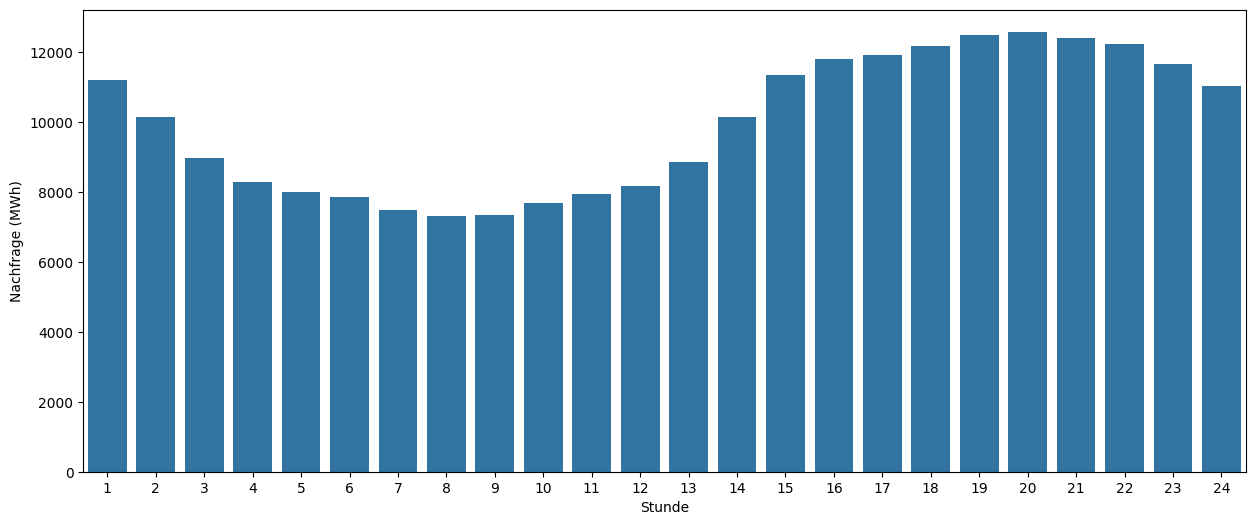

In [6]:
fig, ax = plt.subplots(figsize=(15,6))

demand_plot = sns.barplot(x=list(range(1,25)), y=[d[h] for h in range(1,25)])
demand_plot.set_xticklabels(demand_plot.get_xticklabels());
demand_plot.set(xlabel='Stunde', ylabel='Nachfrage (MWh)');
plt.show()

In [7]:
df_plant_info = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/plant_capacities.csv?raw=true') # replace "small_plant_data" with "large_plant_data" to use the full dataset
# df_plant_info = pd.read_csv('small_plant_data/plant_capacities.csv')

P = set(df_plant_info['Plant'].unique())                          # set of all power plants

plant_type = df_plant_info.set_index('Plant').PlantType.to_dict() # plant type for each plant

P_N = set([i for i in P if plant_type[i]=='NUCLEAR'])             # set of all nuclear plants  

fuel_type = df_plant_info.set_index('Plant').FuelType.to_dict()   # fuel type for each plant

df_plant_info.to_excel(writer, index=False, sheet_name="Kraftwerke")


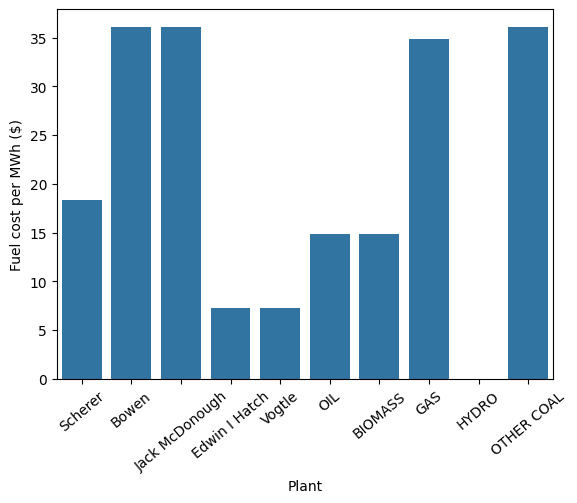

In [8]:
df_fuel_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/fuel_costs.csv?raw=true') 
# df_fuel_costs = pd.read_csv('small_plant_data/fuel_costs.csv')

df_fuel_costs.to_excel(writer, index=False, sheet_name="Brennstoffkosten")

# read the fuel costs and transform it from fuel-type to plant-name
f = {i: df_fuel_costs[df_fuel_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # dictionary of fuel cost for each plant

# plot the fuel costs
fuelcost_plot = sns.barplot(x=list(f.keys()), y=[f[k] for k in f])
fuelcost_plot.set_xticklabels(fuelcost_plot.get_xticklabels(), rotation=40);
fuelcost_plot.set(xlabel='Plant', ylabel='Fuel cost per MWh ($)');
plt.show()

In [9]:
df_oper_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/operating_costs.csv?raw=true')  

df_oper_costs.to_excel(writer, index=False, sheet_name="Betriebskosten")

# df_oper_costs = pd.read_csv('small_plant_data/operating_costs.csv')
o = {i: df_oper_costs[df_oper_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # operating cost/MWh (plant)

In [10]:
df_startup_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/startup_costs.csv?raw=true')

df_startup_costs.to_excel(writer, index=False, sheet_name="Startupkosten")
# df_startup_costs = pd.read_csv('small_plant_data/startup_costs.csv')
s = {i: df_startup_costs[df_startup_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # operating cost/MWh (plant)

t = s.copy() # assume that the cost of shuting down = starting up

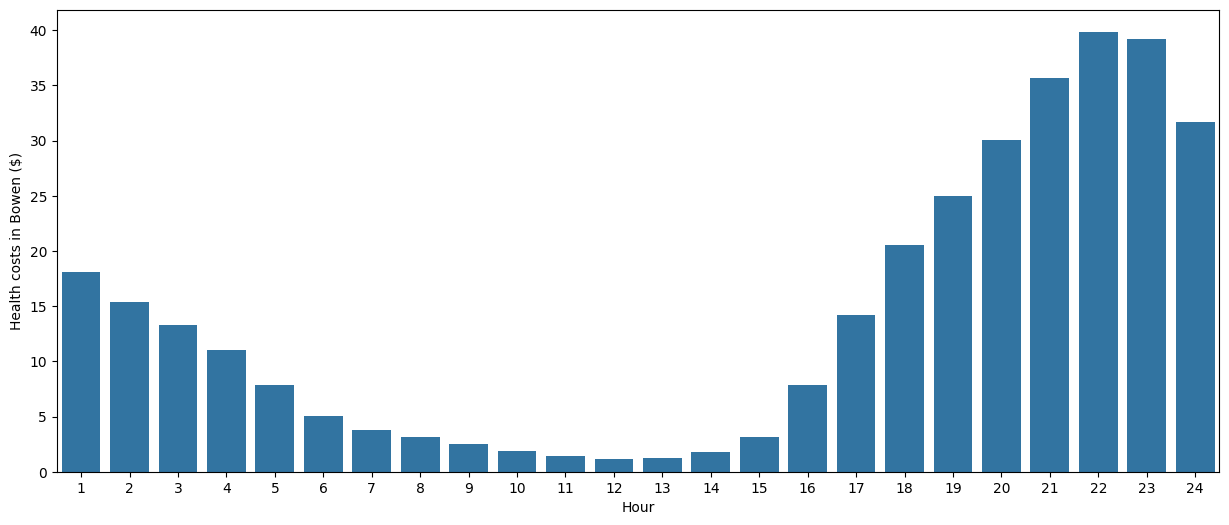

In [11]:
df_health_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/health_costs.csv?raw=true')  
# df_health_costs = pd.read_csv('small_plant_data/health_costs.csv')
a = df_health_costs[(df_health_costs['Year']==2007)&(df_health_costs['Day']==1)].set_index(['Plant','Hour']).to_dict()['Cost'] # operating cost/MWh (plant)
a.update({(i,h): 0 for i in P for h in H if i not in ['Bowen','Jack McDonough','Scherer']})  

df_health_costs.to_excel(writer, index=False, sheet_name="Gesundheitskosten")

fig, ax = plt.subplots(figsize=(15,6)) 
healthcost_plot = sns.barplot(x=list(range(1,25)), y=[a['Bowen',h] for h in range(1,25)])
healthcost_plot.set_xticklabels(healthcost_plot.get_xticklabels());
healthcost_plot.set(xlabel='Hour', ylabel='Health costs in Bowen ($)');
plt.show()

In [12]:
writer.close()